step 1 Poblem Framing

This is a spam detection system. in real world we ofen receive messages from things we did not subscribe for. So we could build a model and we will train it to know which kind of messages are spam and which kind are okay to recive.

input is the messages that are being recived

output is what we want to predict wether they are spam or ham

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

step 2 data understanding

In [25]:
df= pd.read_csv("spam.csv", encoding='latin1') # loading the file
df.head() #checking first 5 rows of the data
df.info() #to see the data types
df.describe() #inspect structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [24]:
#checking for missing data/ potential issues
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


Step 3 EDA

In [26]:
#EDA
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [38]:
#defining feature and labels
x= df['v2'] #raw text
y= df['v1'] #label(ham or spam)
print("assigned succesfully")

assigned succesfully


In [65]:
#visualisations
def show(x , y) :
  plt.bar(x,y)
  plt.figure(figsize=(10,10))
  plt.title('spam vs ham')
  plt.show

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 139 (\x8b) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


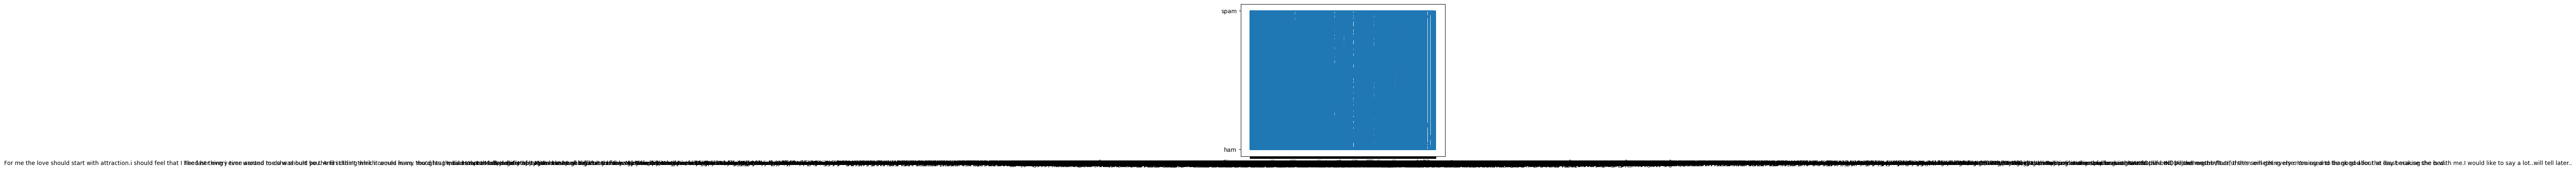

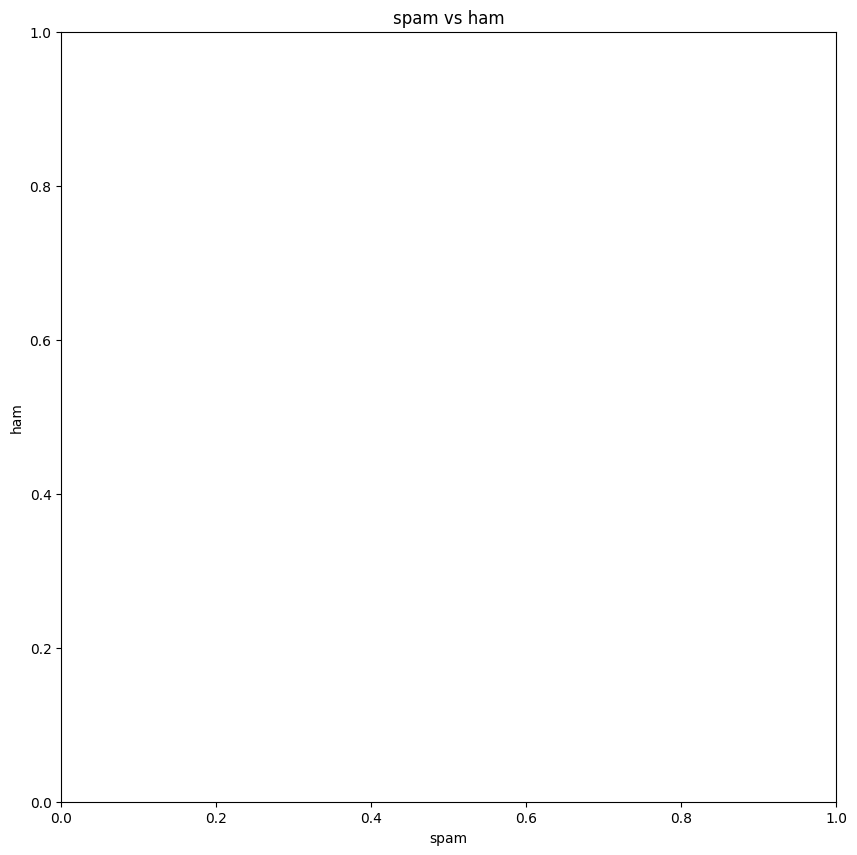

In [71]:
#creating a plot
x= df['v2']
y= df['v1']
plt.plot(x,y)
plt.figure(figsize=(10,10))
plt.xlabel('spam')
plt.ylabel('ham')
plt.title('spam vs ham')
plt.show()

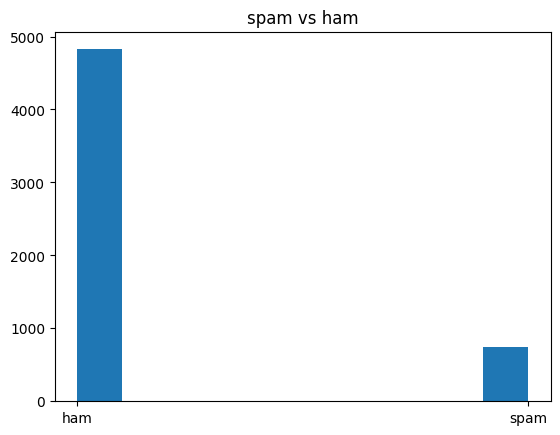

In [110]:
#creating a histogram
plt.hist(df['v1'])
plt.title('spam vs ham')
plt.show()

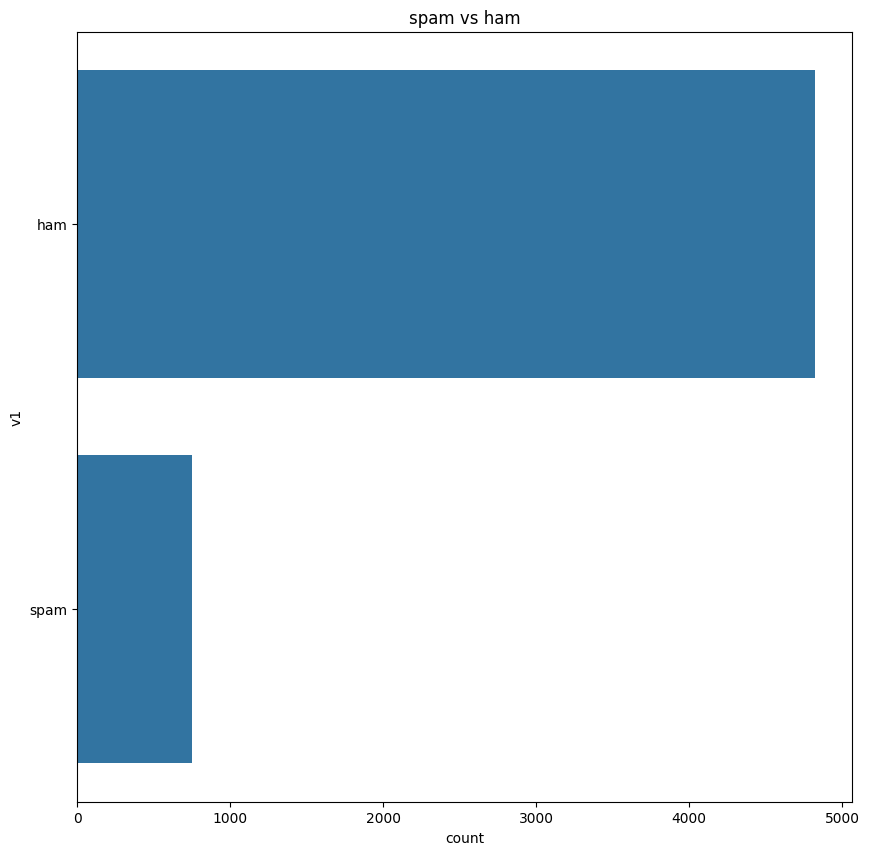

In [102]:
plt.figure(figsize=(10,10))
sns.countplot(df['v1'])
plt.title('spam vs ham')
plt.show()

there are more legitimate messages then spam messages

step 4 code structure

creating reusable functions for preprocessing, prediction, visualisation

In [104]:
def preprocess(text):
  text = text.lower()
  text = text.replace('\n', ' ')
  text = text.replace('\t', ' ')
  text = text.replace('\r', ' ')
  return text
print("preprocessing done")

preprocessing done


prediction

In [109]:

def predict(text):
  text = preprocess(text)
  text = vectorizer.transform([text])
  prediction = model.predict(text)
  return prediction[0]
print("prediction done")

prediction done


step 5 structured design/ oop

implemet a class based component or modular structure

In [63]:
class SpamDetector():
  def __init__(self):
    self.bad_words = ['spam', 'SPAM']
    self.good_words = ['ham', 'HAM']
    self.bad_words_count = 0
    self.good_words_count = 0
print("class created sucessfully")

class created sucessfully


In [ ]:
detector = SpamDetector()
print(detector.bad_words)
print(detector.good_words)
print(detector.bad_words_count)
print(detector.good_words_count)

['spam', 'SPAM']
['ham', 'HAM']
0
0


In [75]:
def predict (text):
  for word in text.split():
    if word in detector.bad_words:
      detector.bad_words_count += 1
    elif word in detector.good_words:
      detector.good_words_count += 1
      return detector.bad_words_count, detector.good_words_count
print("prediction done")

prediction done


step 6 Preprocessing

In [87]:
#natural language processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

#now normalising the data
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


step7 model development


In [93]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer

#train model
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=42)

# countvectorizer
vectorizer = CountVectorizer()

x_train_vectorized = vectorizer.fit_transform(x_train)
x_test_vectorized = vectorizer.transform(x_test)

model = LogisticRegression(max_iter=1000)
model.fit(x_train_vectorized, y_train)


LogisticRegression(max_iter=1000)

i chose logistic regression beacuse its simple and only requires yes / no answers. We only need to predict wether a message is spam or not. Also logistic regression is used for continuous numbers and people keep receiving spam messages

step 8 model evaluation



In [95]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(x_test_vectorized)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1199    3]
 [  32  159]]


In [96]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9748743718592965


model has an accuracy of 0.9748743718592965

step 9 Error analysis

In [97]:
#now doing error analysis
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         ham       0.97      1.00      0.99      1202
        spam       0.98      0.83      0.90       191

    accuracy                           0.97      1393
   macro avg       0.98      0.91      0.94      1393
weighted avg       0.98      0.97      0.97      1393



In [99]:
#failuers
failures = x_test[y_test != y_pred]
print(failures)

683     Hi I'm sue. I am 20 years old and work as a la...
4071    Loans for any purpose even if you have Bad Cre...
3979                                   ringtoneking 84484
751     You have an important customer service announc...
712                 08714712388 between 10am-7pm Cost 10p
1268    Can U get 2 phone NOW? I wanna chat 2 set up m...
730     Email AlertFrom: Jeri StewartSize: 2KBSubject:...
2662    Hello darling how are you today? I would love ...
3130    LookAtMe!: Thanks for your purchase of a video...
4494    Hope this text meets you smiling. If not then ...
1448    As a registered optin subscriber ur draw 4 å£1...
4904    Warner Village 83118 C Colin Farrell in SWAT t...
1468    Hi its LUCY Hubby at meetins all day Fri & I w...
5028    I'd like to tell you my deepest darkest fantas...
2351    Download as many ringtones as u like no restri...
438     Hi hope u get this txt~journey hasnt been gd,n...
2819    INTERFLORA - åÒIt's not too late to order Inte...
1892    CALL 0

In [100]:
#incorrect predictions
incorrect_predictions = x_test[y_test != y_pred]
print(incorrect_predictions)


683     Hi I'm sue. I am 20 years old and work as a la...
4071    Loans for any purpose even if you have Bad Cre...
3979                                   ringtoneking 84484
751     You have an important customer service announc...
712                 08714712388 between 10am-7pm Cost 10p
1268    Can U get 2 phone NOW? I wanna chat 2 set up m...
730     Email AlertFrom: Jeri StewartSize: 2KBSubject:...
2662    Hello darling how are you today? I would love ...
3130    LookAtMe!: Thanks for your purchase of a video...
4494    Hope this text meets you smiling. If not then ...
1448    As a registered optin subscriber ur draw 4 å£1...
4904    Warner Village 83118 C Colin Farrell in SWAT t...
1468    Hi its LUCY Hubby at meetins all day Fri & I w...
5028    I'd like to tell you my deepest darkest fantas...
2351    Download as many ringtones as u like no restri...
438     Hi hope u get this txt~journey hasnt been gd,n...
2819    INTERFLORA - åÒIt's not too late to order Inte...
1892    CALL 0

step 10 streamlit app

step 11

Real life usage
i was not able to make the app due to time constraintS
But